# Wafer Map Defect Pattern Classification - CNN Baseline & Misclassification Analysis

이 노트북은 기존 전처리 결과(`data/processed/*.npy`)를 불러와서 CNN baseline 모델을 다시 학습하고,  
테스트 평가, confusion matrix, normalized confusion matrix, 오분류 Top 20, 오분류 샘플 시각화까지 한 번에 정리하기 위한 새 노트북입니다.

## 실행 전제
- Google Drive에 `wafer-map-defect-xai` 폴더가 있어야 합니다.
- 아래 파일들이 존재해야 합니다.
  - `data/processed/X_train.npy`
  - `data/processed/X_val.npy`
  - `data/processed/X_test.npy`
  - `data/processed/y_train.npy`
  - `data/processed/y_val.npy`
  - `data/processed/y_test.npy`
  - `data/processed/classes.npy`

## 1. Google Drive 마운트

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. 기본 import 및 경로 설정

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = "/content/drive/MyDrive/wafer-map-defect-xai"

DATA_DIR = os.path.join(BASE_DIR, "data")
RAW_DIR = os.path.join(DATA_DIR, "raw")
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")

OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
FIGURE_PATH = os.path.join(OUTPUT_DIR, "figures")
MODEL_PATH = os.path.join(OUTPUT_DIR, "models")
REPORT_PATH = os.path.join(OUTPUT_DIR, "reports")

os.makedirs(FIGURE_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(REPORT_PATH, exist_ok=True)

print("BASE_DIR exists:", os.path.exists(BASE_DIR))
print("PROCESSED_DIR exists:", os.path.exists(PROCESSED_DIR))
print("MODEL_PATH:", MODEL_PATH)
print("FIGURE_PATH:", FIGURE_PATH)
print("REPORT_PATH:", REPORT_PATH)

if os.path.exists(PROCESSED_DIR):
    print("processed files:", os.listdir(PROCESSED_DIR))

BASE_DIR exists: True
PROCESSED_DIR exists: True
MODEL_PATH: /content/drive/MyDrive/wafer-map-defect-xai/outputs/models
FIGURE_PATH: /content/drive/MyDrive/wafer-map-defect-xai/outputs/figures
REPORT_PATH: /content/drive/MyDrive/wafer-map-defect-xai/outputs/reports
processed files: ['X_train.npy', 'X_val.npy', 'X_test.npy', 'y_val.npy', 'y_test.npy', 'y_train.npy', 'classes.npy']


## 3. 전처리된 데이터 로드

In [3]:
X_train = np.load(os.path.join(PROCESSED_DIR, "X_train.npy"))
X_val = np.load(os.path.join(PROCESSED_DIR, "X_val.npy"))
X_test = np.load(os.path.join(PROCESSED_DIR, "X_test.npy"))

y_train = np.load(os.path.join(PROCESSED_DIR, "y_train.npy"))
y_val = np.load(os.path.join(PROCESSED_DIR, "y_val.npy"))
y_test = np.load(os.path.join(PROCESSED_DIR, "y_test.npy"))

classes = np.load(os.path.join(PROCESSED_DIR, "classes.npy"), allow_pickle=True)

print("X_train:", X_train.shape, X_train.dtype)
print("X_val:", X_val.shape, X_val.dtype)
print("X_test:", X_test.shape, X_test.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("y_val:", y_val.shape, y_val.dtype)
print("y_test:", y_test.shape, y_test.dtype)
print("classes:", classes)

X_train: (121065, 64, 64, 1) uint8
X_val: (25942, 64, 64, 1) uint8
X_test: (25943, 64, 64, 1) uint8
y_train: (121065,) int64
y_val: (25942,) int64
y_test: (25943,) int64
classes: ['Center' 'Donut' 'Edge-Loc' 'Edge-Ring' 'Loc' 'Near-full' 'Random'
 'Scratch' 'none']


## 4. 데이터 정상 여부 확인

In [4]:
assert len(X_train) == len(y_train), "X_train과 y_train 개수가 다릅니다."
assert len(X_val) == len(y_val), "X_val과 y_val 개수가 다릅니다."
assert len(X_test) == len(y_test), "X_test와 y_test 개수가 다릅니다."

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))
print("Input shape:", X_train.shape[1:])
print("Number of classes:", len(classes))

Train: 121065
Validation: 25942
Test: 25943
Input shape: (64, 64, 1)
Number of classes: 9


## 5. 이미지 정규화

In [5]:
# 원본 값이 0, 1, 2로 구성되어 있으므로 2.0으로 나누어 0~1 범위로 정규화합니다.
X_train = X_train.astype("float32") / 2.0
X_val = X_val.astype("float32") / 2.0
X_test = X_test.astype("float32") / 2.0

print("X_train dtype:", X_train.dtype)
print("X_train min/max:", X_train.min(), X_train.max())
print("X_val min/max:", X_val.min(), X_val.max())
print("X_test min/max:", X_test.min(), X_test.max())

X_train dtype: float32
X_train min/max: 0.0 1.0
X_val min/max: 0.0 1.0
X_test min/max: 0.0 1.0


## 6. 클래스 분포 확인

In [6]:
train_dist = pd.Series(y_train).value_counts().sort_index()
val_dist = pd.Series(y_val).value_counts().sort_index()
test_dist = pd.Series(y_test).value_counts().sort_index()

dist_df = pd.DataFrame({
    "class": classes,
    "train": train_dist.values,
    "val": val_dist.values,
    "test": test_dist.values
})

dist_df

,class,train,val,test
0,Center,3006,644,644
1,Donut,389,83,83
2,Edge-Loc,3632,778,779
3,Edge-Ring,6776,1452,1452
4,Loc,2515,539,539
5,Near-full,104,23,22
6,Random,606,130,130
7,Scratch,835,179,179
8,none,103202,22114,22115


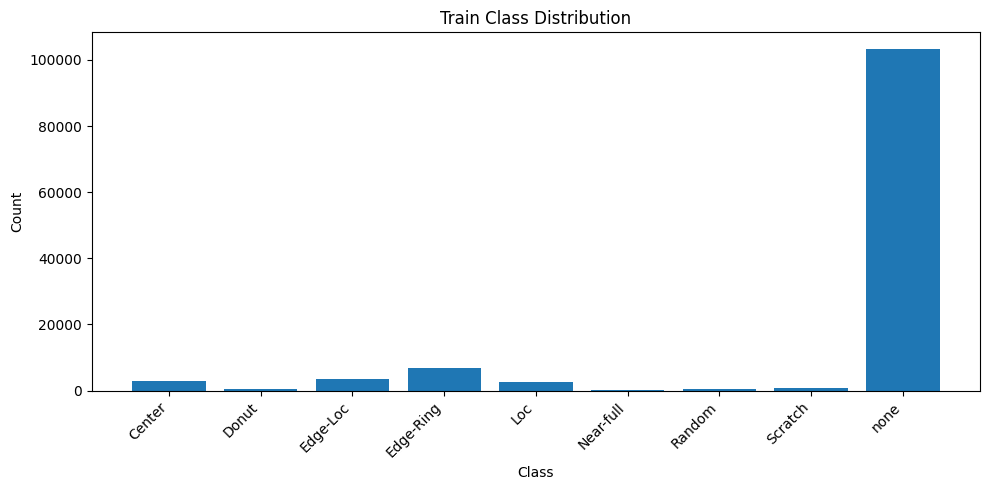

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/figures/train_class_distribution.png


In [7]:
plt.figure(figsize=(10, 5))
plt.bar(dist_df["class"], dist_df["train"])
plt.title("Train Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

save_path = os.path.join(FIGURE_PATH, "train_class_distribution.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

## 7. Class Weight 계산

In [8]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

for idx, weight in class_weight_dict.items():
    print(f"{idx} ({classes[idx]}): {weight:.4f}")

0 (Center): 4.4749
1 (Donut): 34.5801
2 (Edge-Loc): 3.7037
3 (Edge-Ring): 1.9852
4 (Loc): 5.3486
5 (Near-full): 129.3429
6 (Random): 22.1975
7 (Scratch): 16.1098
8 (none): 0.1303


## 8. TensorFlow 설정

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

NUM_CLASSES = len(classes)
INPUT_SHAPE = X_train.shape[1:]

print("NUM_CLASSES:", NUM_CLASSES)
print("INPUT_SHAPE:", INPUT_SHAPE)

TensorFlow version: 2.20.0
NUM_CLASSES: 9
INPUT_SHAPE: (64, 64, 1)


## 9. CNN Baseline 모델 정의

In [10]:
def build_cnn_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])

    return model

model = build_cnn_model(INPUT_SHAPE, NUM_CLASSES)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,440,905 (5.50 MB)

 Trainable params: 1,439,945 (5.49 MB)

 Non-trainable params: 960 (3.75 KB)

## 10. Callback 설정

In [11]:
checkpoint_path = os.path.join(MODEL_PATH, "best_cnn_model.keras")

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("Best model will be saved to:", checkpoint_path)

Best model will be saved to: /content/drive/MyDrive/wafer-map-defect-xai/outputs/models/best_cnn_model.keras


## 11. 모델 학습

In [12]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=128,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/30
946/946 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3002 - loss: 2.2327
Epoch 1: val_loss improved from None to 1.42026, saving model to /content/drive/MyDrive/wafer-map-defect-xai/outputs/models/best_cnn_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/wafer-map-defect-xai/outputs/models/best_cnn_model.keras
946/946 ━━━━━━━━━━━━━━━━━━━━ 44s 36ms/step - accuracy: 0.3264 - loss: 1.7025 - val_accuracy: 0.3408 - val_loss: 1.4203 - learning_rate: 0.0010
Epoch 2/30
944/946 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4250 - loss: 1.3879
Epoch 2: val_loss did not improve from 1.42026
946/946 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.4011 - loss: 1.4327 - val_accuracy: 0.1042 - val_loss: 1.9052 - learning_rate: 0.0010
Epoch 3/30
946/946 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4465 - loss: 1.3631
Epoch 3: val_loss improved from 1.42026 to 1.05694, saving model to /content/drive/MyDrive/wafer-map-defect-xai/outputs/models/best_cnn_model.kera

## 12. 학습 곡선 시각화

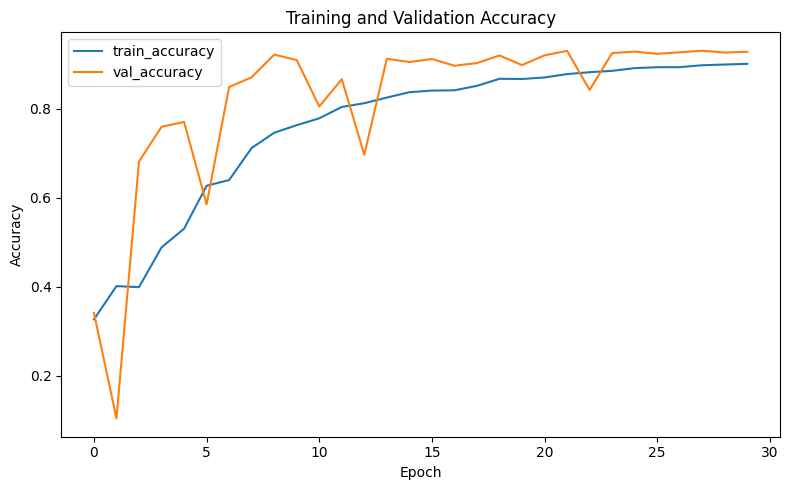

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/figures/cnn_accuracy_curve.png


In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()

save_path = os.path.join(FIGURE_PATH, "cnn_accuracy_curve.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

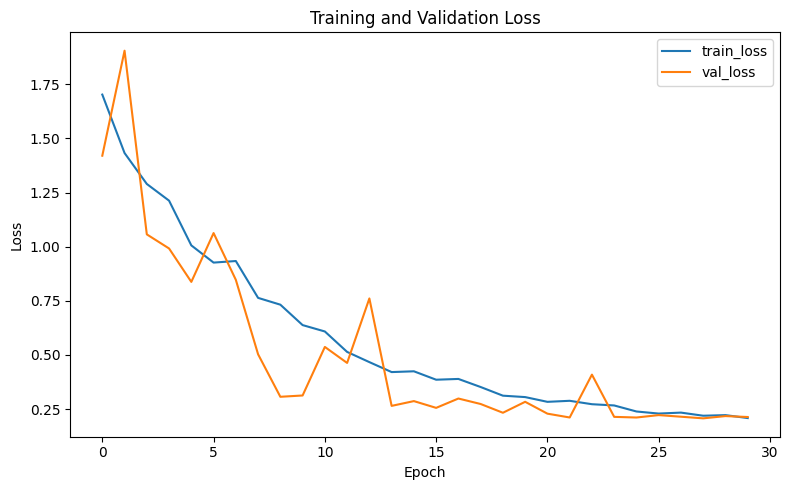

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/figures/cnn_loss_curve.png


In [14]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

save_path = os.path.join(FIGURE_PATH, "cnn_loss_curve.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

## 13. Test Set 평가

In [15]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

811/811 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9302 - loss: 0.2162
Test Loss: 0.21623921394348145
Test Accuracy: 0.9302316904067993


## 14. 예측값 생성 및 Classification Report

In [16]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("y_pred_prob shape:", y_pred_prob.shape)
print("y_pred shape:", y_pred.shape)

report_text = classification_report(y_test, y_pred, target_names=classes)
print(report_text)

report_path = os.path.join(REPORT_PATH, "cnn_baseline_classification_report.txt")
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print("Saved:", report_path)

811/811 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
y_pred_prob shape: (25943, 9)
y_pred shape: (25943,)
              precision    recall  f1-score   support

      Center       0.78      0.95      0.86       644
       Donut       0.77      0.83      0.80        83
    Edge-Loc       0.59      0.84      0.69       779
   Edge-Ring       0.96      0.97      0.97      1452
         Loc       0.58      0.76      0.66       539
   Near-full       0.92      1.00      0.96        22
      Random       0.73      0.88      0.79       130
     Scratch       0.15      0.63      0.24       179
        none       0.99      0.94      0.96     22115

    accuracy                           0.93     25943
   macro avg       0.72      0.87      0.77     25943
weighted avg       0.96      0.93      0.94     25943

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/reports/cnn_baseline_classification_report.txt


## 15. Confusion Matrix

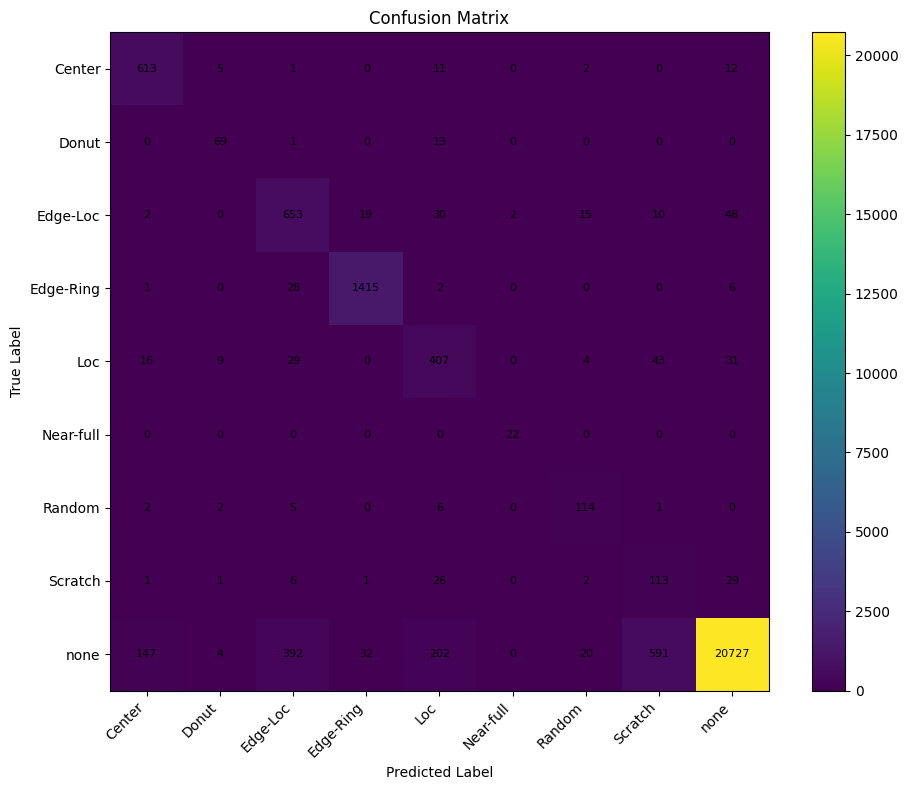

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/figures/confusion_matrix.png


In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(classes)), classes, rotation=45, ha="right")
plt.yticks(np.arange(len(classes)), classes)
plt.colorbar()

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)

plt.tight_layout()

save_path = os.path.join(FIGURE_PATH, "confusion_matrix.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

## 16. Normalized Confusion Matrix

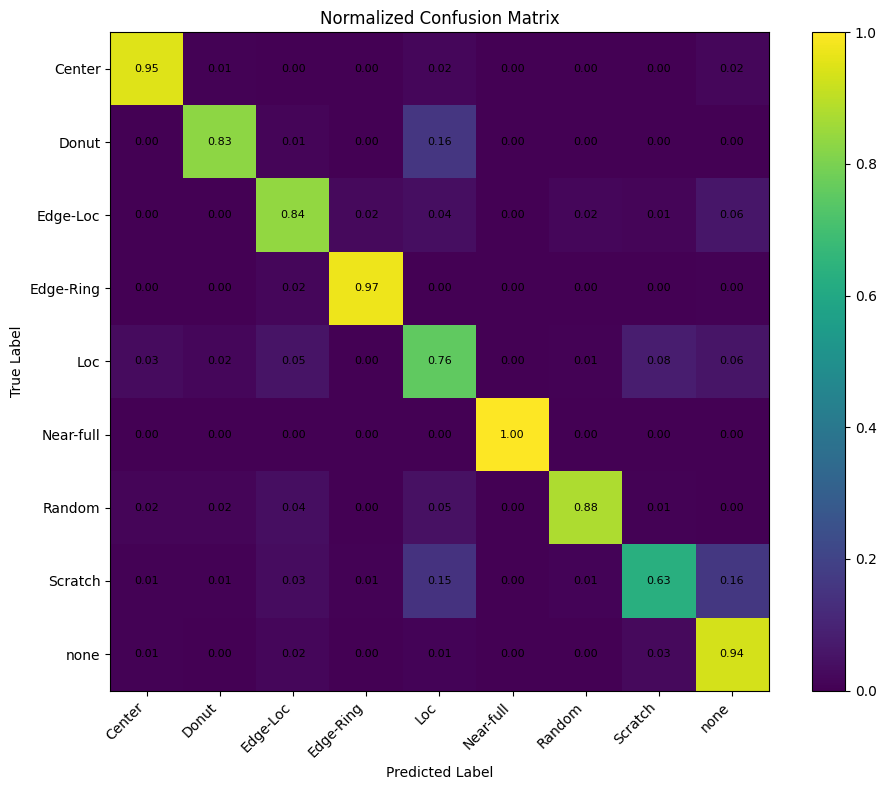

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/figures/normalized_confusion_matrix.png


In [18]:
# true class 기준 정규화
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
plt.imshow(cm_norm)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(classes)), classes, rotation=45, ha="right")
plt.yticks(np.arange(len(classes)), classes)
plt.colorbar()

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(
            j, i,
            f"{cm_norm[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()

save_path = os.path.join(FIGURE_PATH, "normalized_confusion_matrix.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

## 17. 오분류 Top 20 분석

In [19]:
error_df = pd.DataFrame({
    "true": y_test,
    "pred": y_pred
})

error_df = error_df[error_df["true"] != error_df["pred"]].copy()

error_df["true_label"] = error_df["true"].apply(lambda x: classes[x])
error_df["pred_label"] = error_df["pred"].apply(lambda x: classes[x])

top_errors = (
    error_df
    .groupby(["true_label", "pred_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

top20_errors = top_errors.head(20)
top20_errors

,true_label,pred_label,count
42,none,Scratch,591
38,none,Edge-Loc,392
40,none,Loc,202
36,none,Center,147
13,Edge-Loc,none,48
22,Loc,Scratch,43
39,none,Edge-Ring,32
23,Loc,none,31
9,Edge-Loc,Loc,30
20,Loc,Edge-Loc,29


In [20]:
top_error_path = os.path.join(REPORT_PATH, "misclassification_top20.csv")
top20_errors.to_csv(top_error_path, index=False, encoding="utf-8-sig")

print("Saved:", top_error_path)

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/reports/misclassification_top20.csv


## 18. 오분류 샘플 시각화 함수

In [21]:
def show_misclassified_samples(true_label_name, pred_label_name=None, n=12, save=False):
    true_idx = list(classes).index(true_label_name)

    if pred_label_name is None:
        indices = np.where((y_test == true_idx) & (y_pred != true_idx))[0]
        title = f"True {true_label_name} / Pred Wrong"
        file_name = f"misclassified_true_{true_label_name}.png"
    else:
        pred_idx = list(classes).index(pred_label_name)
        indices = np.where((y_test == true_idx) & (y_pred == pred_idx))[0]
        title = f"True {true_label_name} / Pred {pred_label_name}"
        file_name = f"misclassified_true_{true_label_name}_pred_{pred_label_name}.png"

    if len(indices) == 0:
        print("No samples found.")
        return

    selected = indices[:n]

    cols = 4
    rows = int(np.ceil(len(selected) / cols))

    plt.figure(figsize=(cols * 3, rows * 3))

    for i, idx in enumerate(selected):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(X_test[idx].squeeze(), cmap="gray")
        plt.axis("off")
        plt.title(
            f"T: {classes[y_test[idx]]}\nP: {classes[y_pred[idx]]}",
            fontsize=9
        )

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()

    if save:
        save_path = os.path.join(FIGURE_PATH, file_name)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()

## 19. 주요 클래스 오분류 샘플 확인

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/figures/misclassified_true_Scratch.png


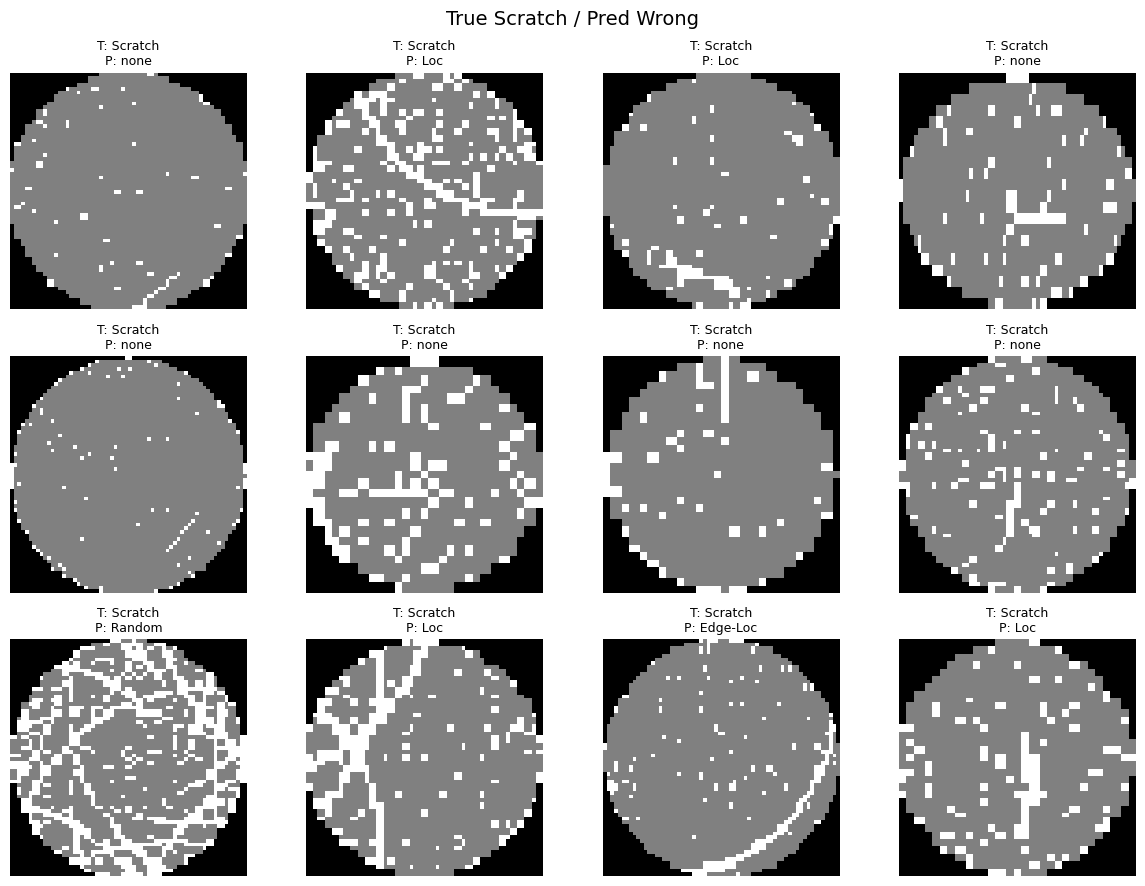

In [22]:
show_misclassified_samples("Scratch", n=12, save=True)

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/figures/misclassified_true_Loc.png


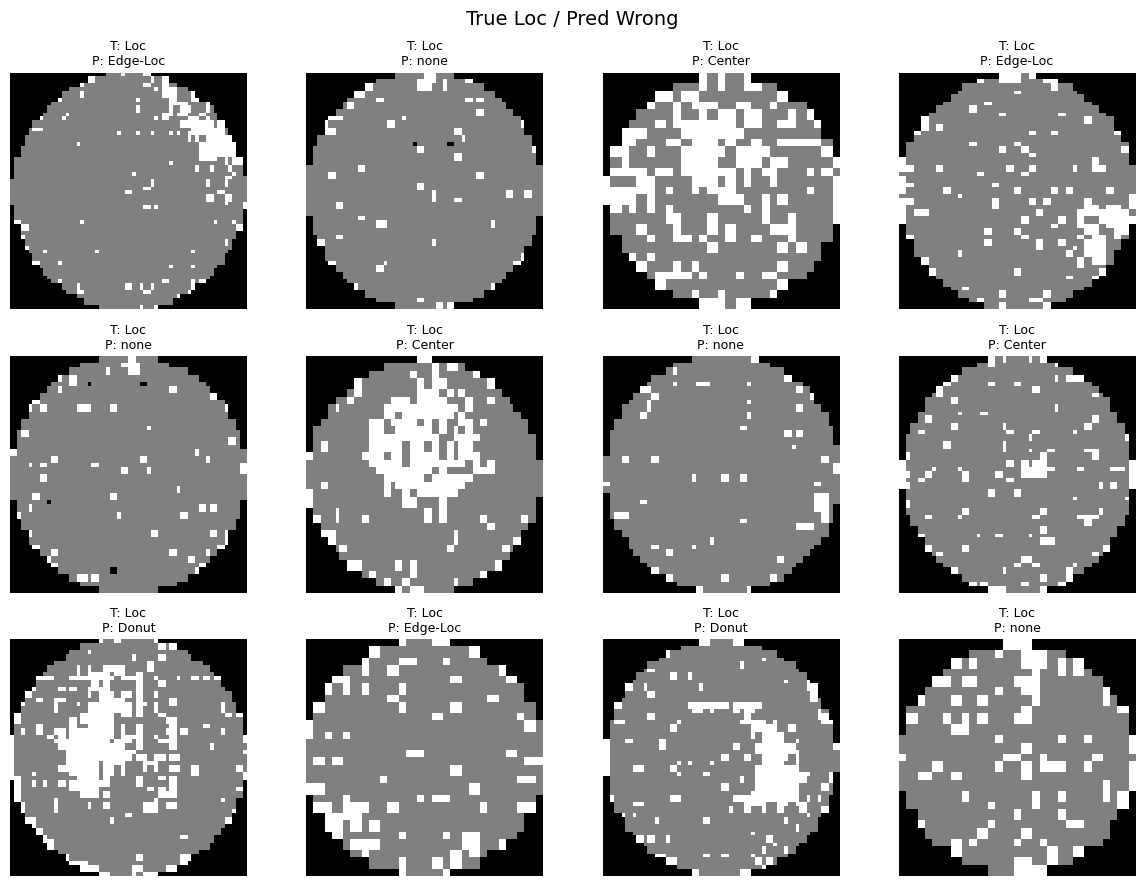

In [23]:
show_misclassified_samples("Loc", n=12, save=True)

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/figures/misclassified_true_Edge-Loc.png


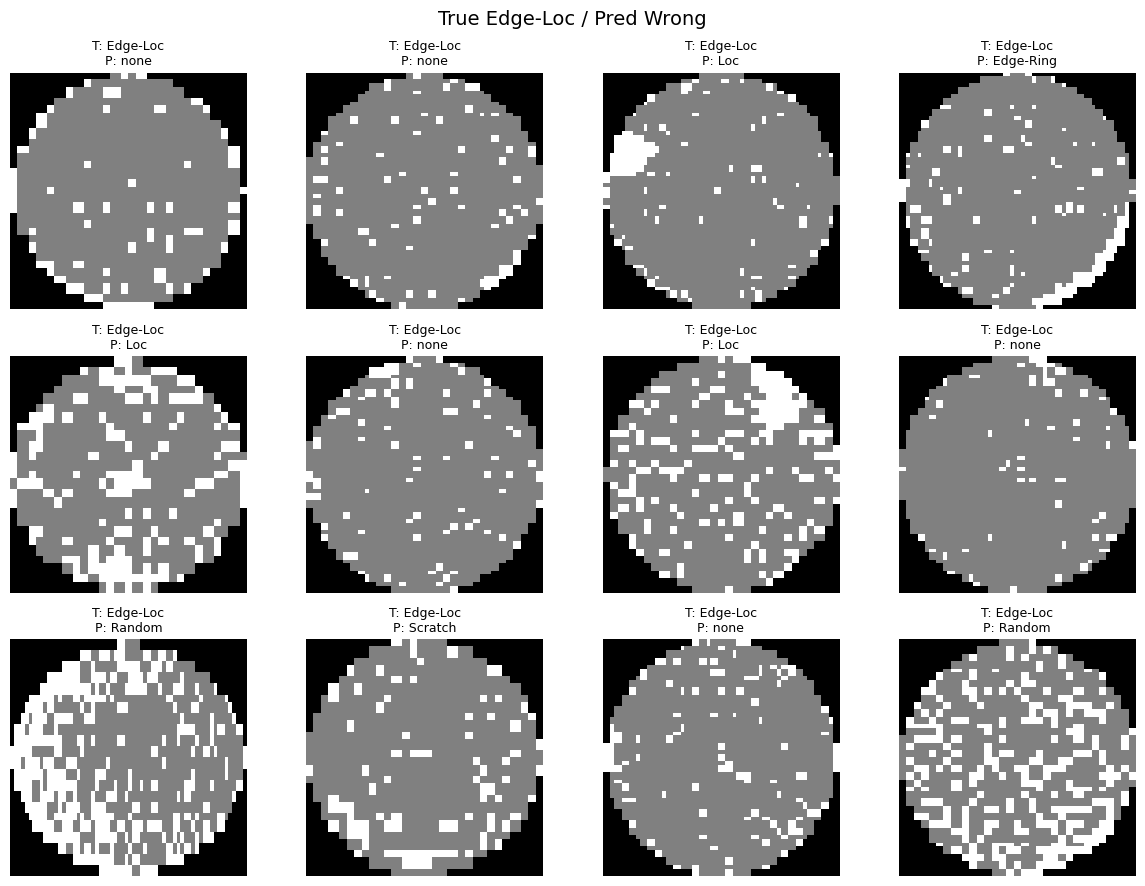

In [24]:
show_misclassified_samples("Edge-Loc", n=12, save=True)

## 20. 특정 오분류 조합 확인

In [25]:
# Top 20 결과를 보고 필요한 조합만 실행하세요.
# 예시:
# show_misclassified_samples("Loc", "Edge-Loc", n=12, save=True)
# show_misclassified_samples("Edge-Loc", "Loc", n=12, save=True)
# show_misclassified_samples("none", "Scratch", n=12, save=True)
# show_misclassified_samples("Scratch", "none", n=12, save=True)

## 21. 결과 요약 Markdown 자동 생성

In [26]:
summary_md = f"""# CNN Baseline Result

## 1. 실험 개요

본 실험은 WM-811K / LSWMD 웨이퍼 맵 데이터셋을 대상으로 CNN baseline 모델을 학습하고, 클래스별 성능과 오분류 패턴을 분석하기 위해 수행하였다.

## 2. 데이터 분할

- Train: {len(X_train):,}
- Validation: {len(X_val):,}
- Test: {len(X_test):,}
- Input shape: {INPUT_SHAPE}
- Classes: {', '.join(map(str, classes))}

## 3. 학습 설정

- Model: CNN Baseline
- Optimizer: Adam
- Loss: Sparse Categorical Crossentropy
- Batch size: 128
- Class weight: Applied
- Early stopping: Applied
- Model checkpoint: Applied

## 4. Test 결과

- Test Loss: {test_loss:.4f}
- Test Accuracy: {test_acc:.4f}

## 5. 해석 시 주의점

전체 accuracy가 높게 나타나더라도, 본 데이터셋은 `none` 클래스가 매우 많은 불균형 구조를 가진다. 따라서 accuracy만으로 모델 성능을 판단하기보다, macro F1-score와 클래스별 precision, recall, f1-score를 함께 확인해야 한다.

## 6. 오분류 분석

Normalized Confusion Matrix와 오분류 Top 20 표를 통해 모델이 어떤 클래스를 주로 혼동하는지 확인하였다. 특히 Scratch, Loc, Edge-Loc 클래스는 시각적 패턴이 애매하거나 데이터 수가 상대적으로 적어 오분류 가능성이 높다.

Scratch 클래스는 실제 Scratch 샘플을 일부 탐지할 수 있지만, Scratch가 아닌 샘플까지 Scratch로 예측하는 false positive 문제가 발생할 수 있다. Loc와 Edge-Loc는 결함이 특정 위치에 집중된다는 점에서 유사하므로 서로 혼동될 가능성이 있다.

## 7. 저장된 산출물

- `outputs/models/best_cnn_model.keras`
- `outputs/figures/confusion_matrix.png`
- `outputs/figures/normalized_confusion_matrix.png`
- `outputs/reports/cnn_baseline_classification_report.txt`
- `outputs/reports/misclassification_top20.csv`
"""

summary_path = os.path.join(REPORT_PATH, "cnn_baseline_result.md")

with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_md)

print("Saved:", summary_path)

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/reports/cnn_baseline_result.md


In [27]:
# ============================================================
# Experiment A: CNN without class_weight
# ============================================================

EXPERIMENT_NAME = "cnn_without_class_weight"

MODEL_SAVE_PATH_NO_CW = os.path.join(
    MODEL_PATH,
    "best_cnn_without_class_weight.keras"
)

REPORT_SAVE_PATH_NO_CW = os.path.join(
    REPORT_PATH,
    "classification_report_without_class_weight.txt"
)

CM_SAVE_PATH_NO_CW = os.path.join(
    FIGURE_PATH,
    "confusion_matrix_without_class_weight.png"
)

NORM_CM_SAVE_PATH_NO_CW = os.path.join(
    FIGURE_PATH,
    "normalized_confusion_matrix_without_class_weight.png"
)

TOP_ERROR_SAVE_PATH_NO_CW = os.path.join(
    REPORT_PATH,
    "misclassification_top20_without_class_weight.csv"
)

print("Experiment:", EXPERIMENT_NAME)
print("Model save path:", MODEL_SAVE_PATH_NO_CW)

Experiment: cnn_without_class_weight
Model save path: /content/drive/MyDrive/wafer-map-defect-xai/outputs/models/best_cnn_without_class_weight.keras


# class_weight 없는 새 모델 만들기

In [28]:
from tensorflow.keras import layers, models

model_no_cw = models.Sequential([
    layers.Input(shape=INPUT_SHAPE),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model_no_cw.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_no_cw.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,440,905 (5.50 MB)

 Trainable params: 1,439,945 (5.49 MB)

 Non-trainable params: 960 (3.75 KB)

# 콜백 설정

In [29]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks_no_cw = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=MODEL_SAVE_PATH_NO_CW,
        monitor="val_loss",
        save_best_only=True
    )
]

print("Callbacks ready.")

Callbacks ready.


# class_weight 없이 학습

In [30]:
history_no_cw = model_no_cw.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=128,
    callbacks=callbacks_no_cw
)

Epoch 1/30
946/946 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - accuracy: 0.9255 - loss: 0.3133 - val_accuracy: 0.9477 - val_loss: 0.2198
Epoch 2/30
946/946 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.9463 - loss: 0.1814 - val_accuracy: 0.9350 - val_loss: 0.3470
Epoch 3/30
946/946 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - accuracy: 0.9531 - loss: 0.1527 - val_accuracy: 0.9524 - val_loss: 0.1997
Epoch 4/30
946/946 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.9577 - loss: 0.1354 - val_accuracy: 0.9642 - val_loss: 0.1265
Epoch 5/30
946/946 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.9608 - loss: 0.1229 - val_accuracy: 0.9567 - val_loss: 0.1725
Epoch 6/30
946/946 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - accuracy: 0.9644 - loss: 0.1084 - val_accuracy: 0.9524 - val_loss: 0.2218
Epoch 7/30
946/946 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - accuracy: 0.9665 - loss: 0.1001 - val_accuracy: 0.9659 - val_loss: 0.1158
Epoch 8/30
946/946 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.9699 - loss: 0.0885 - 

# 테스트 평가

In [31]:
test_loss_no_cw, test_acc_no_cw = model_no_cw.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss without class_weight: {test_loss_no_cw:.4f}")
print(f"Test Accuracy without class_weight: {test_acc_no_cw:.4f}")

Test Loss without class_weight: 0.1142
Test Accuracy without class_weight: 0.9675


# 예측값 생성

In [32]:
import numpy as np

y_pred_prob_no_cw = model_no_cw.predict(X_test)
y_pred_no_cw = np.argmax(y_pred_prob_no_cw, axis=1)

print("y_pred_prob_no_cw shape:", y_pred_prob_no_cw.shape)
print("y_pred_no_cw shape:", y_pred_no_cw.shape)

811/811 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step
y_pred_prob_no_cw shape: (25943, 9)
y_pred_no_cw shape: (25943,)


# classification report 생성

In [33]:
from sklearn.metrics import classification_report

report_no_cw = classification_report(
    y_test,
    y_pred_no_cw,
    target_names=classes,
    digits=4
)

print(report_no_cw)

with open(REPORT_SAVE_PATH_NO_CW, "w", encoding="utf-8") as f:
    f.write(report_no_cw)

print("Saved:", REPORT_SAVE_PATH_NO_CW)

              precision    recall  f1-score   support

      Center     0.9456    0.9177    0.9314       644
       Donut     0.7976    0.8072    0.8024        83
    Edge-Loc     0.8836    0.6727    0.7638       779
   Edge-Ring     0.9535    0.9883    0.9706      1452
         Loc     0.7968    0.5529    0.6528       539
   Near-full     0.7917    0.8636    0.8261        22
      Random     0.8629    0.8231    0.8425       130
     Scratch     0.6923    0.2011    0.3117       179
        none     0.9761    0.9958    0.9859     22115

    accuracy                         0.9675     25943
   macro avg     0.8556    0.7580    0.7875     25943
weighted avg     0.9643    0.9675    0.9640     25943

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/reports/classification_report_without_class_weight.txt


# confusion matrix 생성


In [34]:
from sklearn.metrics import confusion_matrix

cm_no_cw = confusion_matrix(y_test, y_pred_no_cw)

print(cm_no_cw)

[[  591     6     1     0     2     0     2     0    42]
 [    0    67     1     0     4     1     2     0     8]
 [    2     0   524    35    16     4     7     0   191]
 [    0     0     5  1435     0     0     1     0    11]
 [   19     8    25     1   298     0     1    16   171]
 [    0     0     3     0     0    19     0     0     0]
 [    3     2     2     1     0     0   107     0    15]
 [    0     1     3     2    34     0     2    36   101]
 [   10     0    29    31    20     0     2     0 22023]]


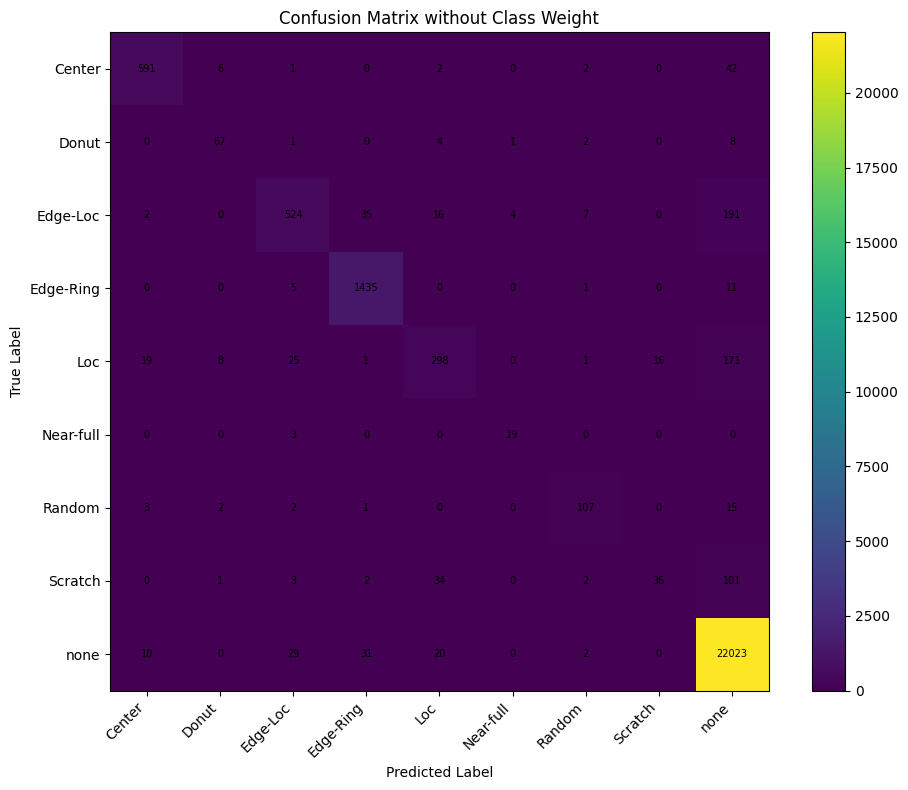

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/figures/confusion_matrix_without_class_weight.png


In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(cm_no_cw)
plt.title("Confusion Matrix without Class Weight")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(classes)), classes, rotation=45, ha="right")
plt.yticks(np.arange(len(classes)), classes)
plt.colorbar()

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(
            j, i,
            str(cm_no_cw[i, j]),
            ha="center",
            va="center",
            fontsize=7
        )

plt.tight_layout()
plt.savefig(CM_SAVE_PATH_NO_CW, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", CM_SAVE_PATH_NO_CW)

# normalized confusion matrix 저장

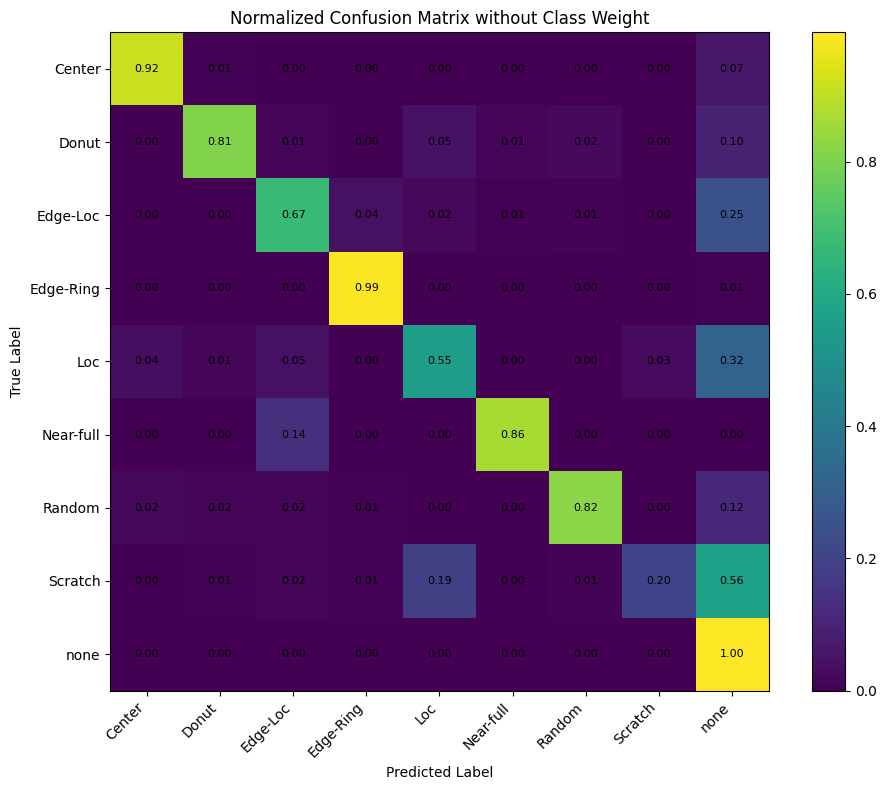

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/figures/normalized_confusion_matrix_without_class_weight.png


In [36]:
cm_norm_no_cw = cm_no_cw.astype("float") / cm_no_cw.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
plt.imshow(cm_norm_no_cw)
plt.title("Normalized Confusion Matrix without Class Weight")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(classes)), classes, rotation=45, ha="right")
plt.yticks(np.arange(len(classes)), classes)
plt.colorbar()

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(
            j, i,
            f"{cm_norm_no_cw[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.savefig(NORM_CM_SAVE_PATH_NO_CW, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", NORM_CM_SAVE_PATH_NO_CW)

# 오분류 Top 20 생성

In [37]:
import pandas as pd

error_df_no_cw = pd.DataFrame({
    "true": y_test,
    "pred": y_pred_no_cw
})

error_df_no_cw = error_df_no_cw[
    error_df_no_cw["true"] != error_df_no_cw["pred"]
].copy()

error_df_no_cw["true_label"] = error_df_no_cw["true"].apply(lambda x: classes[x])
error_df_no_cw["pred_label"] = error_df_no_cw["pred"].apply(lambda x: classes[x])

top_errors_no_cw = (
    error_df_no_cw
    .groupby(["true_label", "pred_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(top_errors_no_cw.head(20))

top_errors_no_cw.head(20).to_csv(
    TOP_ERROR_SAVE_PATH_NO_CW,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", TOP_ERROR_SAVE_PATH_NO_CW)

,true_label,pred_label,count
15,Edge-Loc,none,191
25,Loc,none,171
37,Scratch,none,101
4,Center,none,42
11,Edge-Loc,Edge-Ring,35
35,Scratch,Loc,34
40,none,Edge-Ring,31
39,none,Edge-Loc,29
21,Loc,Edge-Loc,25
41,none,Loc,20


Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/reports/misclassification_top20_without_class_weight.csv


In [38]:
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

# without class_weight 지표
acc_no_cw = accuracy_score(y_test, y_pred_no_cw)
macro_f1_no_cw = f1_score(y_test, y_pred_no_cw, average="macro")
weighted_f1_no_cw = f1_score(y_test, y_pred_no_cw, average="weighted")

precision_no_cw, recall_no_cw, f1_no_cw, support_no_cw = precision_recall_fscore_support(
    y_test,
    y_pred_no_cw,
    labels=np.arange(len(classes))
)

summary_no_cw = pd.DataFrame({
    "class": classes,
    "precision": precision_no_cw,
    "recall": recall_no_cw,
    "f1": f1_no_cw,
    "support": support_no_cw
})

display(summary_no_cw)

print("Accuracy without class_weight:", acc_no_cw)
print("Macro F1 without class_weight:", macro_f1_no_cw)
print("Weighted F1 without class_weight:", weighted_f1_no_cw)

,class,precision,recall,f1,support
0,Center,0.945600,0.917702,0.931442,644
1,Donut,0.797619,0.807229,0.802395,83
2,Edge-Loc,0.883642,0.672657,0.763848,779
3,Edge-Ring,0.953488,0.988292,0.970578,1452
4,Loc,0.796791,0.552876,0.652793,539
5,Near-full,0.791667,0.863636,0.826087,22
6,Random,0.862903,0.823077,0.842520,130
7,Scratch,0.692308,0.201117,0.311688,179
8,none,0.976110,0.995840,0.985876,22115


Accuracy without class_weight: 0.9675056855413792
Macro F1 without class_weight: 0.7874698133762819
Weighted F1 without class_weight: 0.9639891610134304
